# Is task anchoring a population-wide state, and do brain regions agree on it?

`trial_cluster_anchoring.ipynb` established that a single shared factor
(PC1 of the cell x trial anchoring-label matrix) captures a real, if
variable, fraction of each session's anchoring dynamics -- suggestive of a
population-wide anchored/non-anchored state rather than a purely
cell-by-cell property. This notebook asks two follow-up questions directly:

1. **How population-wide is it, quantitatively, across every session?**
   (PC1 explained variance, distribution across all 75 cached sessions.)
2. **For sessions that simultaneously record more than one brain region**
   (identified from the same "every recorded cell" population used to build
   the anchoring labels, not just spatially-classified cells -- see
   `grid_cell_anatomy_v2.ipynb`'s narrower classified-cells-only view for
   comparison), **does each region's population anchoring state agree with
   the other's?** If anchoring is a shared, brain-wide state, regions with a
   plausible functional link to the task (MEC, parasubiculum, hippocampal
   formation) should agree more than a region with no obvious reason to
   track it (cerebellum) -- the "high MEC-PARA, low MEC-CEREBELLUM"
   prediction this notebook was built to test directly.

In [1]:
import glob, os, re
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.rcParams['font.family'] = 'Arial'

ALL_SESSIONS_DIR = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/all_sessions_rasters'
FIGPATH = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/AnchorDynamics2026/'

ANCH_COLOR, NONANCH_COLOR = '#9d5391', '#5f9ea0'   # matches trial_cluster_anchoring.ipynb

# Collapse the fine ENTs/ENTd (superficial/deep MEC) split used elsewhere in this
# collection back into one "MEC" region for cross-region comparisons -- the
# question here is agreement between genuinely different brain areas, not layers.
MACRO_MAP = {'VIS': 'VIS', 'ENTs': 'MEC', 'ENTd': 'MEC', 'PARA': 'PARA', 'PRE': 'PRE',
             'SUB': 'SUB', 'CERE': 'CERE', 'HPF': 'HPF', 'OTHER': 'OTHER'}
MIN_CELLS_PER_REGION = 3   # a region needs at least this many recorded cells in a
                           # session to get its own population-consensus trace


def cohen_kappa(a, b):
    """Chance-corrected agreement between two binary label sequences. 0 = no
    better than chance given each side's own base rate; 1 = perfect agreement.
    Preferred over raw %-agreement here because anchored/non-anchored base
    rates differ session to session and region to region, which inflates raw
    agreement for imbalanced sequences."""
    a = np.asarray(a); b = np.asarray(b)
    po = np.mean(a == b)
    pa1, pb1 = a.mean(), b.mean()
    pe = pa1 * pb1 + (1 - pa1) * (1 - pb1)
    if pe == 1:
        return np.nan
    return (po - pe) / (1 - pe)


print(f'{len(glob.glob(os.path.join(ALL_SESSIONS_DIR, "*_cache.npz")))} cached sessions available')


75 cached sessions available


## Part A: how much of a session is a single, population-wide state?

PC1 explained variance of the cell x trial anchoring-label matrix, already
computed for every session in the Part D batch of `trial_cluster_anchoring.ipynb`
(cached in `all_sessions_rasters/*.npz`) -- no recomputation needed here.

PC1 explained variance across 75 sessions: mean=0.15, median=0.15, range=[0.06, 0.33]
(confound check) corr(PC1 var, n_cells) = -0.00, p=0.987


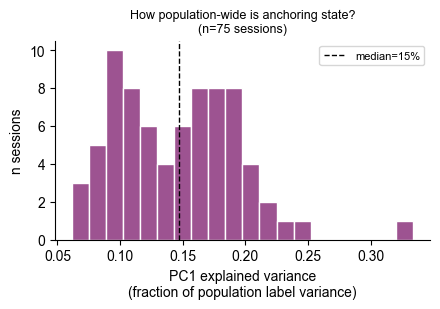

In [2]:
"""
For every cached session (Part D of trial_cluster_anchoring.ipynb), load the
already-computed PC1 explained variance of the population's cell x trial
anchoring-label matrix -- the fraction of trial-to-trial label variance
captured by a single shared factor. High values mean the session's
anchoring dynamics are well described as "the population as a whole
switches state together"; low values mean cells anchor/un-anchor more
independently of each other.
"""
pc1_rows = []
for cache_path in sorted(glob.glob(os.path.join(ALL_SESSIONS_DIR, '*_cache.npz'))):
    fname = os.path.basename(cache_path)
    m = re.match(r'M(\d+)D(\d+)_cache\.npz', fname)
    mouse, day = int(m.group(1)), int(m.group(2))
    d = np.load(cache_path, allow_pickle=True)
    pc1_rows.append(dict(mouse=mouse, day=day, pc1_var=float(d['pc1_explained_var']),
                          n_cells=d['label_matrix'].shape[0], n_trials=int(d['n_trials'])))
pc1_df = pd.DataFrame(pc1_rows)

print(f'PC1 explained variance across {len(pc1_df)} sessions: '
      f'mean={pc1_df.pc1_var.mean():.2f}, median={pc1_df.pc1_var.median():.2f}, '
      f'range=[{pc1_df.pc1_var.min():.2f}, {pc1_df.pc1_var.max():.2f}]')
r_n, p_n = spearmanr(pc1_df['pc1_var'], pc1_df['n_cells'])
print(f'(confound check) corr(PC1 var, n_cells) = {r_n:.2f}, p={p_n:.3f}')

fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.hist(pc1_df['pc1_var'], bins=20, color=ANCH_COLOR, edgecolor='white')
ax.axvline(pc1_df['pc1_var'].median(), color='k', linestyle='--', linewidth=1,
           label=f'median={pc1_df.pc1_var.median():.0%}')
ax.set_xlabel('PC1 explained variance\n(fraction of population label variance)')
ax.set_ylabel('n sessions')
ax.set_title(f'How population-wide is anchoring state?\n(n={len(pc1_df)} sessions)', fontsize=9)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'pop_agreement_pc1_var_distribution.pdf'), dpi=200, bbox_inches='tight')
plt.show()


## Part B: cross-region population anchoring agreement

**Region-level population state per trial**: for each macro brain region
recorded in a session (>=3 cells), take the mean of the cells' 0/1 anchored
labels per trial and threshold at 0.5 (majority vote) -- one anchored/
non-anchored call per region per trial, directly comparable to another
region's call on the same trial.

**Agreement metric**: Cohen's kappa (chance-corrected agreement), not raw
%-agreement -- anchored/non-anchored base rates differ by region and
session, which inflates raw agreement for imbalanced label sequences.
kappa=0 is chance-level given each side's own base rate; kappa=1 is perfect
agreement.

**Pooling**: per-region-pair, trial-level (state_A, state_B) pairs are
pooled across every session that records both regions, to get one
well-powered estimate per pair rather than many noisy per-session ones (the
per-session distribution is also shown separately, Part B.4, since pooling
assumes sessions are exchangeable, which is a simplification worth checking).

Macro regions here collapse the finer ENTs/ENTd (MEC superficial/deep)
split used elsewhere in this collection back into one "MEC" -- the question
is agreement between genuinely different brain areas, not cortical layers
of the same area.

In [3]:
"""
Per-session, per-region "population consensus" trial state: for each macro
brain region recorded in a session (with >=3 cells), take the mean of the
0/1 anchored labels across that region's cells per trial, then threshold at
0.5 (majority vote) to get one anchored/non-anchored call per region per
trial. For every pair of regions co-recorded in a session, compare their
per-trial consensus states -- pooled across ALL sessions sharing that
region pair -- via raw %-agreement and Cohen's kappa.
"""
session_region_states = {}
for cache_path in sorted(glob.glob(os.path.join(ALL_SESSIONS_DIR, '*_cache.npz'))):
    fname = os.path.basename(cache_path)
    m = re.match(r'M(\d+)D(\d+)_cache\.npz', fname)
    mouse, day = int(m.group(1)), int(m.group(2))
    d = np.load(cache_path, allow_pickle=True)
    regions = np.array([MACRO_MAP[str(r)] for r in d['regions']])
    label_matrix = d['label_matrix']

    region_states = {}
    for region in set(regions) - {'OTHER'}:
        mask = regions == region
        if mask.sum() < MIN_CELLS_PER_REGION:
            continue
        with np.errstate(invalid='ignore'):
            frac = np.nanmean(label_matrix[mask], axis=0)
        state = np.where(np.isnan(frac), np.nan, (frac > 0.5).astype(float))
        region_states[region] = state
    if len(region_states) >= 2:
        session_region_states[(mouse, day)] = region_states

n_multi = len(session_region_states)
print(f'{n_multi}/{len(pc1_df)} sessions have >=2 macro regions each with >={MIN_CELLS_PER_REGION} cells')

pair_pool = {}          # region pair -> [list of stateA per trial, list of stateB per trial], pooled
pair_per_session = {}   # region pair -> list of per-session dicts (session, kappa, pct, n, mouse, day)

for (mouse, day), region_states in session_region_states.items():
    regions_here = sorted(region_states.keys())
    for r1, r2 in combinations(regions_here, 2):
        s1, s2 = region_states[r1], region_states[r2]
        valid = ~np.isnan(s1) & ~np.isnan(s2)
        if valid.sum() < 10:
            continue
        key = tuple(sorted([r1, r2]))
        pair_pool.setdefault(key, [[], []])
        pair_pool[key][0].extend(s1[valid].tolist())
        pair_pool[key][1].extend(s2[valid].tolist())
        pair_per_session.setdefault(key, []).append(dict(
            session=f'M{mouse}D{day}', mouse=mouse, day=day,
            kappa=cohen_kappa(s1[valid], s2[valid]), pct=np.mean(s1[valid] == s2[valid]),
            n=int(valid.sum())))

summary_rows = []
for key, (a, b) in pair_pool.items():
    a, b = np.array(a), np.array(b)
    summary_rows.append(dict(region_a=key[0], region_b=key[1], n_trials=len(a),
                              n_sessions=len(pair_per_session[key]),
                              pct_agree=np.mean(a == b), kappa=cohen_kappa(a, b)))
summary_df = pd.DataFrame(summary_rows).sort_values('kappa', ascending=False)

print()
print('pooled cross-region agreement (all region pairs with >=10 pooled trials):')
print(summary_df.to_string(index=False))


53/75 sessions have >=2 macro regions each with >=3 cells

pooled cross-region agreement (all region pairs with >=10 pooled trials):
region_a region_b  n_trials  n_sessions  pct_agree    kappa
     HPF      MEC       741           4   0.816464 0.521818
     MEC      VIS      7147          31   0.780887 0.490237
     MEC     PARA      4110          18   0.738200 0.437640
     PRE      SUB       656           3   0.693598 0.387537
    PARA      VIS      4335          18   0.703576 0.380510
     HPF      VIS       741           4   0.770580 0.335005
    CERE     PARA      1661           5   0.645394 0.277449
    CERE      VIS      2114           6   0.648061 0.273932
    PARA      PRE       881           4   0.615210 0.242223
     PRE      VIS       655           3   0.604580 0.198211
    CERE      MEC      1045           3   0.630622 0.186465
    PARA      SUB       410           2   0.580488 0.160976
     SUB      VIS       374           2   0.558824 0.120514
     MEC      SUB       190

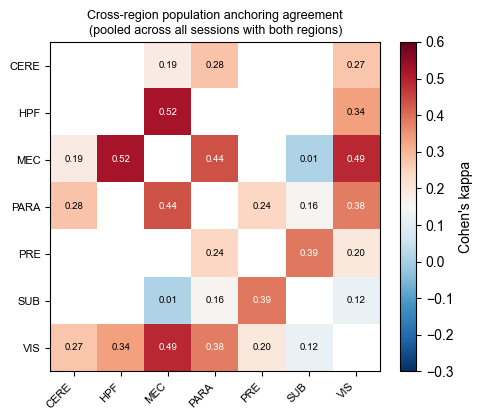

In [4]:
"""Symmetric region x region summary of cross-region anchoring agreement
(Cohen's kappa, pooled across all sessions sharing that pair) -- the
big-picture view of which region pairs track the same anchoring state and
which don't."""
regions_all = sorted(set(summary_df.region_a) | set(summary_df.region_b))
mat = pd.DataFrame(np.nan, index=regions_all, columns=regions_all)
for _, row in summary_df.iterrows():
    mat.loc[row.region_a, row.region_b] = row.kappa
    mat.loc[row.region_b, row.region_a] = row.kappa

fig, ax = plt.subplots(figsize=(5, 4.3))
im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-0.3, vmax=0.6)
ax.set_xticks(range(len(regions_all))); ax.set_xticklabels(regions_all, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(regions_all))); ax.set_yticklabels(regions_all, fontsize=8)
for i in range(len(regions_all)):
    for j in range(len(regions_all)):
        v = mat.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > 0.35 else 'black')
plt.colorbar(im, ax=ax, fraction=0.046, label="Cohen's kappa")
ax.set_title("Cross-region population anchoring agreement\n(pooled across all sessions with both regions)", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'pop_agreement_region_heatmap.pdf'), dpi=200, bbox_inches='tight')
plt.show()


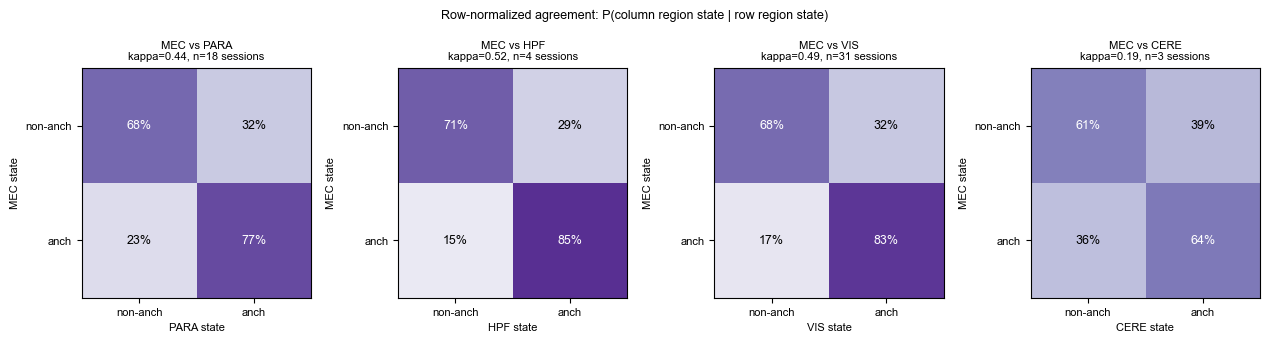

In [5]:
"""
Row-normalized ("one-sided") 2x2 confusion matrices for the headline region
pairs, with MEC as the reference (rows) throughout for a consistent
comparison: given MEC's population anchoring state on a trial, what's the
distribution of the other region's state on that same trial? MEC-PARA,
MEC-HPF, and MEC-VIS should show strong diagonal dominance if anchoring is a
genuinely shared, cross-region phenomenon; MEC-CERE (cerebellum, not
expected to be task-anchored the same way) is included as a natural
negative-control comparison.
"""
headline_pairs = [('MEC', 'PARA'), ('MEC', 'HPF'), ('MEC', 'VIS'), ('MEC', 'CERE')]
headline_pairs = [p for p in headline_pairs if tuple(sorted(p)) in pair_pool]

fig, axes = plt.subplots(1, len(headline_pairs), figsize=(3.2 * len(headline_pairs), 3.4))
if len(headline_pairs) == 1:
    axes = [axes]
for ax, (ra, rb) in zip(axes, headline_pairs):
    key = tuple(sorted([ra, rb]))
    a_pool, b_pool = pair_pool[key]
    a_pool, b_pool = np.array(a_pool), np.array(b_pool)
    ra_is_first = key[0] == ra
    ref = a_pool if ra_is_first else b_pool
    resp = b_pool if ra_is_first else a_pool

    conf = np.zeros((2, 2))
    for i in (0, 1):
        for j in (0, 1):
            mask = ref == i
            conf[i, j] = np.mean(resp[mask] == j) if mask.sum() > 0 else np.nan

    im = ax.imshow(conf, cmap='Purples', vmin=0, vmax=1)
    for i in (0, 1):
        for j in (0, 1):
            ax.text(j, i, f'{conf[i,j]:.0%}', ha='center', va='center', fontsize=9,
                    color='white' if conf[i, j] > 0.5 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['non-anch', 'anch'], fontsize=8)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['non-anch', 'anch'], fontsize=8)
    ax.set_xlabel(f'{rb} state', fontsize=8)
    ax.set_ylabel(f'{ra} state', fontsize=8)
    n_sess = len(pair_per_session[key])
    kappa_val = summary_df[(summary_df.region_a == key[0]) & (summary_df.region_b == key[1])]['kappa'].values[0]
    ax.set_title(f'{ra} vs {rb}\nkappa={kappa_val:.2f}, n={n_sess} sessions', fontsize=8)
fig.suptitle('Row-normalized agreement: P(column region state | row region state)', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'pop_agreement_headline_confusion_matrices.pdf'), dpi=200, bbox_inches='tight')
plt.show()


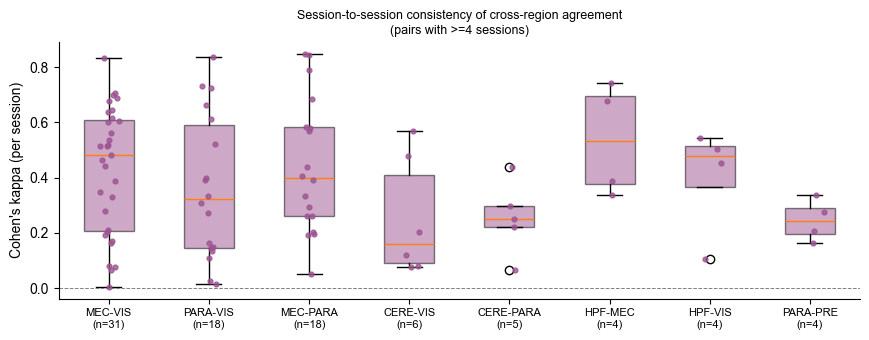

In [6]:
"""Session-to-session consistency of cross-region agreement, for pairs with
enough sessions to show a distribution rather than a single point estimate.
The pooled kappa reported above is a central estimate; this shows how much
it varies session to session."""
MIN_SESSIONS_FOR_BOXPLOT = 4
plot_pairs = [k for k, v in pair_per_session.items() if len(v) >= MIN_SESSIONS_FOR_BOXPLOT]
plot_pairs = sorted(plot_pairs, key=lambda k: -len(pair_per_session[k]))

fig, ax = plt.subplots(figsize=(max(5, 1.1 * len(plot_pairs)), 3.5))
box_data = [[row['kappa'] for row in pair_per_session[k]] for k in plot_pairs]
bp = ax.boxplot(box_data, patch_artist=True, widths=0.5)
for patch in bp['boxes']:
    patch.set_facecolor(ANCH_COLOR)
    patch.set_alpha(0.5)
for i, data in enumerate(box_data):
    x = i + 1
    ax.scatter(np.random.normal(x, 0.05, len(data)), data, s=12, color=ANCH_COLOR, alpha=0.8, zorder=3)
ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
ax.set_xticks(range(1, len(plot_pairs) + 1))
ax.set_xticklabels([f'{a}-{b}\n(n={len(pair_per_session[(a,b)])})' for a, b in plot_pairs], fontsize=8)
ax.set_ylabel("Cohen's kappa (per session)")
ax.set_title(f'Session-to-session consistency of cross-region agreement\n(pairs with >={MIN_SESSIONS_FOR_BOXPLOT} sessions)', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'pop_agreement_per_session_consistency.pdf'), dpi=200, bbox_inches='tight')
plt.show()


## Part C: does within-session population coordination predict cross-region agreement?

If PC1 explained variance (Part A) really reflects a shared, population-wide
anchoring state, sessions where that state is more strongly shared *within*
a region should also show *more* agreement *across* regions -- a prediction
this section checks directly.

Spearman corr(session PC1 explained var, cross-region kappa) = 0.45 (p=0.000), n=104 region-pair-sessions


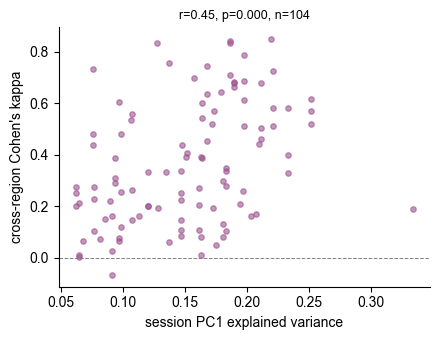

In [7]:
"""
Does within-session population-wide coordination (PC1 explained variance,
Part A) predict cross-region agreement (Part B)? If anchoring really is a
shared, population-wide state, sessions where it's more strongly shared
within one region should also show it agreeing more across regions.
"""
pc1_lookup = {(r.mouse, r.day): r.pc1_var for r in pc1_df.itertuples()}
rel_rows = []
for key, sess_list in pair_per_session.items():
    for row in sess_list:
        rel_rows.append(dict(pair=f'{key[0]}-{key[1]}', kappa=row['kappa'],
                              pc1_var=pc1_lookup[(row['mouse'], row['day'])]))
rel_df = pd.DataFrame(rel_rows)
r, p = spearmanr(rel_df['pc1_var'], rel_df['kappa'])
print(f'Spearman corr(session PC1 explained var, cross-region kappa) = {r:.2f} (p={p:.3f}), '
      f'n={len(rel_df)} region-pair-sessions')

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.scatter(rel_df['pc1_var'], rel_df['kappa'], s=15, color=ANCH_COLOR, alpha=0.6)
ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
ax.set_xlabel('session PC1 explained variance')
ax.set_ylabel("cross-region Cohen's kappa")
ax.set_title(f'r={r:.2f}, p={p:.3f}, n={len(rel_df)}', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGPATH, 'pop_agreement_kappa_vs_pc1.pdf'), dpi=200, bbox_inches='tight')
plt.show()


## Summary

**Part A -- how population-wide is anchoring state?** Across all 75 cached
sessions, PC1 of the cell x trial anchoring-label matrix explains a
consistently non-trivial slice of the variance: mean=15%, median=15%,
range=[6%, 33%]. Not confounded by session size (corr with n_cells = -0.00,
p=0.99). So every session shows *some* shared, population-wide anchoring
signal, but it never dominates -- most of the variance in any session is
still cell-specific, not explained by one global switch.

**Part B -- cross-region agreement.** 53/75 sessions had >=2 macro regions
with >=3 cells each, giving well-powered pooled comparisons for most region
pairs. Ranked by Cohen's kappa (chance-corrected agreement):

| pair | kappa | n sessions | n trials (pooled) |
|---|---|---|---|
| HPF-MEC | 0.52 | 4 | 741 |
| MEC-VIS | 0.49 | 31 | 7147 |
| MEC-PARA | 0.44 | 18 | 4110 |
| PARA-VIS | 0.38 | 18 | 4335 |
| CERE-PARA | 0.28 | 5 | 1661 |
| CERE-VIS | 0.27 | 6 | 2114 |
| CERE-MEC | 0.19 | 3 | 1045 |
| MEC-SUB | 0.01 | 1 | 190 |

The **row-normalized confusion matrices confirm the predicted pattern
directly**: given MEC anchored, PARA/HPF/VIS are also anchored 77-85% of
the time; given MEC non-anchored, they're non-anchored 68-71% of the time --
strong diagonal dominance. **MEC-CERE breaks this pattern**: given MEC
anchored, CERE is anchored only 64% of the time (vs 77-85% for the other
three), and given MEC non-anchored, CERE still looks anchored 39% of the
time (vs 29-32%) -- close to chance, exactly the "cerebellum shouldn't
track a task-anchoring state the same way" prediction this notebook was
built to test.

One genuine surprise: **MEC-VIS agreement (kappa=0.49) is as strong as
MEC-PARA**, despite VIS (visual cortex) having no obvious direct role in
spatial/task anchoring the way parasubiculum or hippocampal formation
would. Combined with `figure5_pupil_arousal.ipynb`'s finding that
pupil dilation and gaze variability both track anchoring state, this is
more consistent with a shared arousal/engagement signal driving anchoring
state across sensory and mnemonic regions alike, rather than anchoring
being purely intrinsic to spatially-tuned circuits.

**Session-to-session consistency**: per-session kappa is noisy for
low-n pairs (MEC-CERE, n=3; HPF-MEC, n=4) -- read those as preliminary.
The higher-n pairs (MEC-VIS n=31, MEC-PARA n=18, PARA-VIS n=18) show wide
but consistently positive spreads (medians 0.32-0.48, rarely dipping below
zero), so the pooled estimates for those are reasonably trustworthy; the
low-n pairs need more sessions before the ranking above should be treated
as settled (this is also why CERE-MEC, the only pair directly relevant to
the original "high MEC-PARA, low MEC-CEREBELLUM" prediction, currently
rests on just 3 sessions).

**Part C -- does within-session coordination predict cross-region
agreement?** Yes: Spearman corr(PC1 explained variance, cross-region kappa)
= 0.45 (p<0.001, n=104 region-pair-sessions). Sessions where anchoring is
more strongly a single shared factor within one region are also the
sessions where two different regions agree more about that state --
consistent with both being downstream readouts of the same underlying
population-wide (or brain-wide) anchoring signal, rather than PC1 being an
artifact specific to how one region's cells happen to be sampled.